# Feynmac-Kac Steering

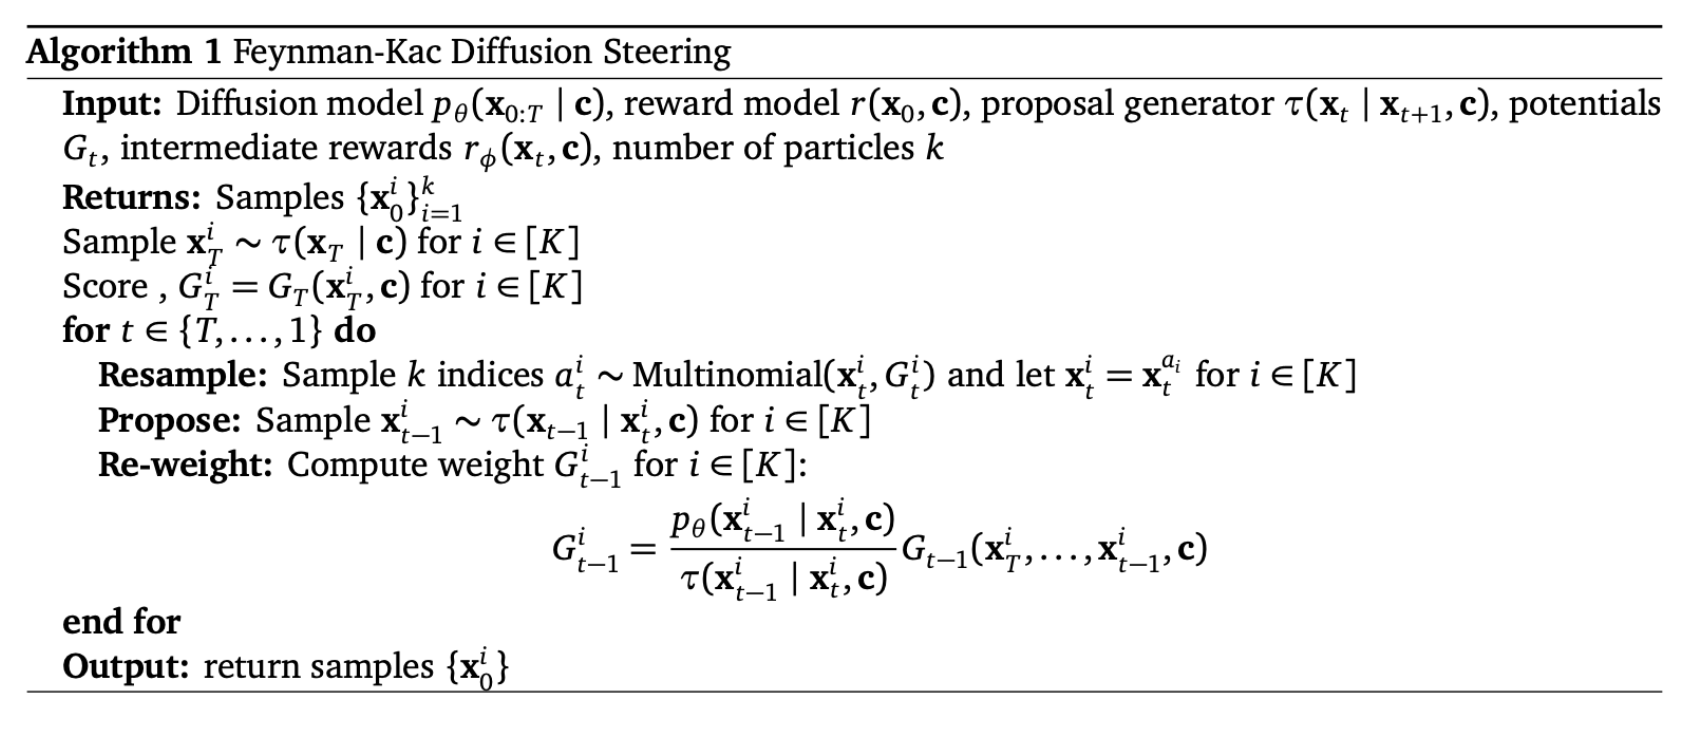
 Source: (https://arxiv.org/pdf/2501.06848)

In [1]:
_TEXT_PROMPT = "A woman on vacation in Bali"

#### 1. Context

Experiment with SMC methods for inference time diffusion model alignment. For simplicity we can fix the context to the prompt before.

The proposal distribution is a glass flow transition, the reward model is the installed image reward. Fix $k=4$, though would expect "better" samples with higher beam width. Can experiment with the number of "glass flows" or sampling steps. 


#### 2. Import Image Reward

In [2]:
import os
print(os.listdir("."))

['glass_flows_tutorial.code-workspace', 'ckpts', 'glass_flows_tutorial.ipynb', 'models', '__pycache__', 'velocity_epsilon_conversion.ipynb', 'README.md', 'figures', 'fks_image_example.png', 'other_visualizations', 'glass_flows_klein_exp.ipynb', '.ipynb_checkpoints', 'fks_steering_glass_flows_klein.ipynb', '.git', 'glass_flows.py']


In [3]:
import urllib.request
import os

path = "/Users/annhe/anaconda3/envs/glass_flows/lib/python3.12/site-packages/hpsv2/src/open_clip/"
url = "https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz"
urllib.request.urlretrieve(url, os.path.join(path, "bpe_simple_vocab_16e6.txt.gz"))
print("done")

done


In [4]:
import hpsv2
from PIL import Image

# Single image + prompt → scalar score
result = hpsv2.score(
    [Image.open("fks_image_example.png")],
    "your generation prompt here",
    hps_version="v2.1"  # use v2.1, it's trained on higher quality data
)
print(result)  # list of floats, higher = more preferred

/Users/annhe/anaconda3/envs/glass_flows/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/annhe/anaconda3/envs/glass_flows/lib/python3.12/site-packages/hpsv2/img_score.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


[np.float32(0.18085846)]


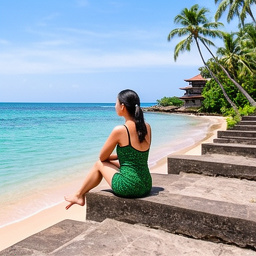

In [5]:
from IPython.display import display

display(Image.open("fks_image_example.png"))

#### 3. Load Models

In [6]:
import torch
from IPython.display import display
from glass_flows import (
    GlassFlow, FlowModelCFG, sample_gaussian_latent, decode_and_display,
    _IMAGE_HEIGHT, _IMAGE_WIDTH,
)
from flux2.util import load_flow_model, load_ae
from flux2.text_encoder import Qwen3Embedder
from flux2.sampling import batched_prc_img

device = "mps"
dtype = torch.bfloat16

flow_model = load_flow_model("flux.2-klein-base-4b", device=device)
text_encoder = Qwen3Embedder(model_spec="Qwen/Qwen3-4B", device=device)
auto_encoder = load_ae("flux.2-klein-base-4b", device=device)

flow_model_cfg = FlowModelCFG(flow_model=flow_model, text_encoder=text_encoder, guidance=4.0)
glass_flow = GlassFlow(fm_model=flow_model_cfg)

Loading /Users/annhe/.cache/huggingface/hub/models--black-forest-labs--FLUX.2-klein-base-4B/snapshots/a3b4f4849157f664bdbc776fd7453c2783562f4d/flux-2-klein-base-4b.safetensors for the FLUX.2 weights


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading /Users/annhe/.cache/huggingface/hub/models--black-forest-labs--FLUX.2-dev/snapshots/26afe3a78bb242c0a8bb181dcc8937bb16e5c66c/ae.safetensors for the AutoEncoder weights


#### 4. Feynman-Kac Sampling Loop

The proposal $\tau(x_{t-1} \mid x_t, c)$ is a GLASS transition. Intermediate potentials $G_t = 1$ (uniform); the final potential $G_0$ is the HPSv2 reward score.

In [7]:
torch.set_grad_enabled(False)

k = 4
n_transitions = 6
t_backbone = torch.linspace(0, 1, n_transitions)  # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# ── Initialize: sample k particles from the prior ──────────────────────────
X_list = []
for _ in range(k):
    noise = sample_gaussian_latent(1, _IMAGE_HEIGHT, _IMAGE_WIDTH)
    z_t, _ = batched_prc_img(noise)
    X_list.append(z_t)                          # each (1, 256, 128)
X = torch.cat(X_list, dim=0)                    # (k, 256, 128)

# X_ids are positional — identical for every particle
_, X_ids = batched_prc_img(sample_gaussian_latent(1, _IMAGE_HEIGHT, _IMAGE_WIDTH))

# G_T = uniform (log-space: all zeros)
log_weights = torch.zeros(k, dtype=torch.float32)

print(f"k={k} particles | backbone: {[round(t.item(), 2) for t in t_backbone]}")

# ── Main loop ──────────────────────────────────────────────────────────────
for step_idx in range(n_transitions - 1):
    t_start = t_backbone[step_idx]
    t_end   = t_backbone[step_idx + 1]
    is_last = (step_idx == n_transitions - 2)

    print(f"\nStep {step_idx}: t {t_start:.2f} → {t_end:.2f}")

    # 1. Resample ────────────────────────────────────────────────────────────
    weights = torch.softmax(log_weights, dim=0)
    indices = torch.multinomial(weights, num_samples=k, replacement=True)
    X = X[indices]
    print(f"  resample indices: {indices.tolist()}  weights: {[f'{w:.3f}' for w in weights.tolist()]}")

    # 2. Propose: GLASS transition τ(x_{t+1} | x_t, c) ─────────────────────
    X_next = []
    for i in range(k):
        x_next = glass_flow.sample_glass_transition(
            X_t=X[i:i+1],
            prompt=_TEXT_PROMPT,
            n_steps=10,
            t_start=t_start,
            t_end=t_end,
            corr_rho=0.4,
            dtype=torch.float32,
            device=device,
            precdtype=torch.float32,
        )
        X_next.append(x_next)
    X = torch.cat(X_next, dim=0)               # (k, 256, 128), float32

    # 3. Re-weight ───────────────────────────────────────────────────────────
    if is_last:
        # Final potential G_0 = HPSv2 reward
        scores = []
        for i in range(k):
            img = decode_and_display(X[i:i+1].to(dtype), X_ids, auto_encoder)
            score = float(hpsv2.score([img], _TEXT_PROMPT, hps_version="v2.1")[0])
            scores.append(score)
            print(f"  particle {i}: HPSv2 = {score:.4f}")
        log_weights = torch.tensor(scores, dtype=torch.float32)
    else:
        # Intermediate potentials G_t = 1 (uniform)
        log_weights = torch.zeros(k, dtype=torch.float32)

print(f"\nFinal log-weights: {log_weights.tolist()}")

k=4 particles | backbone: [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

Step 0: t 0.00 → 0.20
  resample indices: [2, 3, 0, 0]  weights: ['0.250', '0.250', '0.250', '0.250']

Step 1: t 0.20 → 0.40
  resample indices: [3, 3, 3, 1]  weights: ['0.250', '0.250', '0.250', '0.250']

Step 2: t 0.40 → 0.60
  resample indices: [2, 0, 2, 1]  weights: ['0.250', '0.250', '0.250', '0.250']

Step 3: t 0.60 → 0.80
  resample indices: [3, 2, 2, 0]  weights: ['0.250', '0.250', '0.250', '0.250']

Step 4: t 0.80 → 1.00
  resample indices: [2, 3, 3, 0]  weights: ['0.250', '0.250', '0.250', '0.250']
  particle 0: HPSv2 = 0.3044
  particle 1: HPSv2 = 0.3073
  particle 2: HPSv2 = 0.3048
  particle 3: HPSv2 = 0.2775

Final log-weights: [0.3044339716434479, 0.30727770924568176, 0.30482423305511475, 0.2774694263935089]


Particle 0  HPSv2=0.3044  weight=0.251


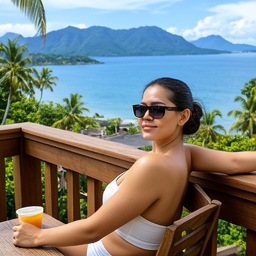

Particle 1  HPSv2=0.3073  weight=0.252


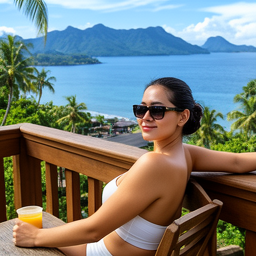

Particle 2  HPSv2=0.3048  weight=0.252


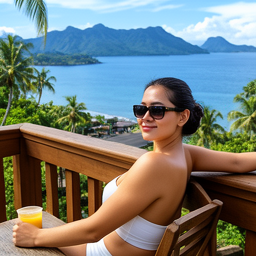

Particle 3  HPSv2=0.2775  weight=0.245


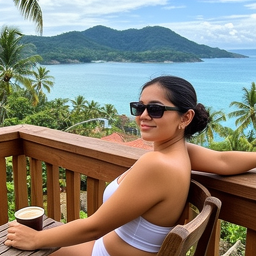

In [8]:
# Display all k final particles with their HPSv2 scores
final_weights = torch.softmax(log_weights, dim=0)
for i in range(k):
    score = log_weights[i].item()
    weight = final_weights[i].item()
    print(f"Particle {i}  HPSv2={score:.4f}  weight={weight:.3f}")
    img = decode_and_display(X[i:i+1].to(dtype), X_ids, auto_encoder)
    display(img)